Runtime initialization
GPU detected and enabled: /physical_device:GPU:0

Loading dataset
Training samples: 560000
Testing samples:  38000

Text preprocessing setup
Fitting vectorizer on training text...
Vectorizer ready.

Model construction


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_1            │ (None, 100)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 100, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 100, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 72)             │         4,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 72)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            73 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,424,785 (5.44 MB)

 Trainable params: 1,424,785 (5.44 MB)

 Non-trainable params: 0 (0.00 B)


Model training
Epoch 1/5
8750/8750 ━━━━━━━━━━━━━━━━━━━━ 192s 21ms/step - accuracy: 0.8340 - loss: 0.3471 - val_accuracy: 0.9074 - val_loss: 0.2267
Epoch 2/5
8750/8750 ━━━━━━━━━━━━━━━━━━━━ 185s 21ms/step - accuracy: 0.9047 - loss: 0.2334 - val_accuracy: 0.9107 - val_loss: 0.2186
Epoch 3/5
8750/8750 ━━━━━━━━━━━━━━━━━━━━ 186s 21ms/step - accuracy: 0.9114 - loss: 0.2174 - val_accuracy: 0.9158 - val_loss: 0.2039
Epoch 4/5
8750/8750 ━━━━━━━━━━━━━━━━━━━━ 186s 21ms/step - accuracy: 0.9214 - loss: 0.1962 - val_accuracy: 0.9209 - val_loss: 0.1918
Epoch 5/5
8750/8750 ━━━━━━━━━━━━━━━━━━━━ 186s 21ms/step - accuracy: 0.9280 - loss: 0.1807 - val_accuracy: 0.9247 - val_loss: 0.1847
Restoring model weights from the end of the best epoch: 5.
Model saved to /kaggle/working/sentiment_lstm_v2.keras

Evaluation metrics
594/594 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9225 - loss: 0.1882
Validation accuracy: 0.9249
Validation loss:     0.1838


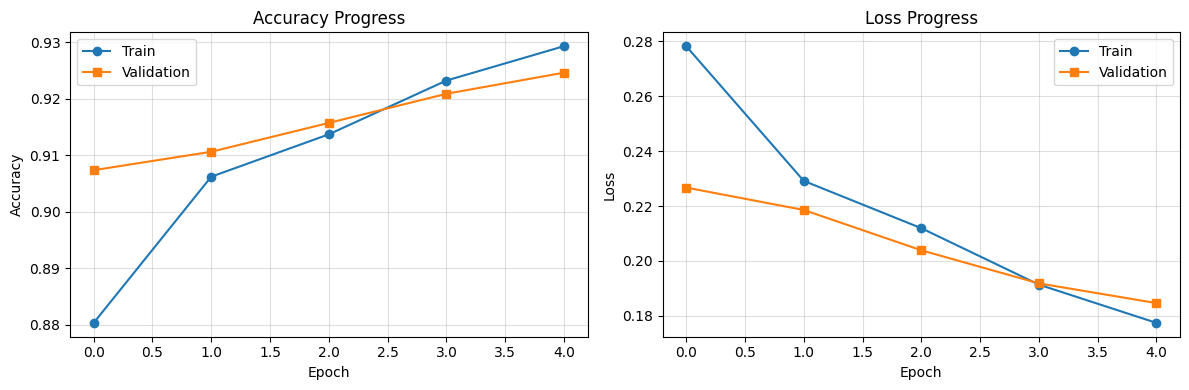


Confusion matrix & classification report
594/594 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step


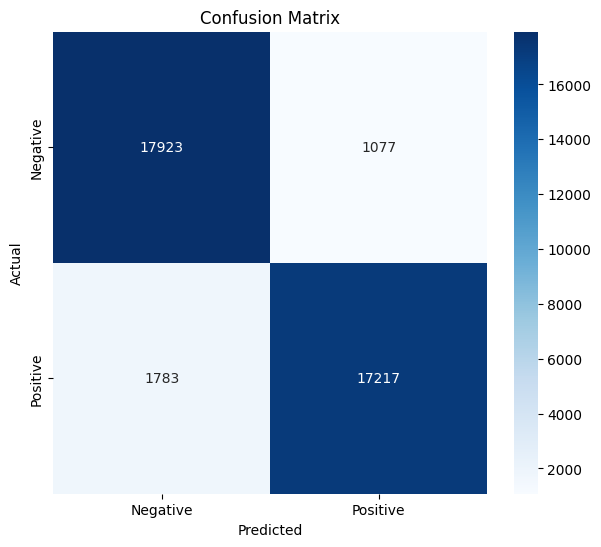

              precision    recall  f1-score   support

    Negative       0.91      0.94      0.93     19000
    Positive       0.94      0.91      0.92     19000

    accuracy                           0.92     38000
   macro avg       0.93      0.92      0.92     38000
weighted avg       0.93      0.92      0.92     38000


Sentiment inference demo

Testing on random reviews from dataset:

Input: "Was not impressed, and will not return."
Predicted label: Negative  |  Confidence: 99.7%

Input: "I went in to purchase overalls and was treated so rudely I had to walk out even though he had the item I wanted.  I will never step foot in this place..."
Predicted label: Negative  |  Confidence: 99.6%

Input: "This place really is horrible... Every time I wind up getting convinced to go here, I always walk out feeling like my pocket has been picked. The food..."
Predicted label: Negative  |  Confidence: 99.9%

Input: "First time visit.....  enjoyed their little cheese biscuits .... Had the ri

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import tensorflow_datasets as tfds

from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import TextVectorization
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc


print("Runtime initialization")

gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    try:
        tf.config.set_visible_devices(gpu_devices[0], 'GPU')
        tf.config.experimental.set_memory_growth(gpu_devices[0], True)
        print(f"GPU detected and enabled: {gpu_devices[0].name}")
    except RuntimeError as e:
        print("GPU configuration error:", e)
else:
    print("Running on CPU (no GPU found).")


MODEL_PATH = "/kaggle/working/sentiment_lstm_v2.keras"

# Core hyperparameters
VOCAB_LIMIT = 10000
MAX_SEQ_LEN = 100
EMB_DIM = 128
BATCH_SZ = 64
EPOCH_COUNT = 5
PATIENCE_STOP = 2


print("\nLoading dataset")

(train_data, test_data), info = tfds.load(
    "yelp_polarity_reviews",
    split=["train", "test"],
    as_supervised=True,
    shuffle_files=True,
    with_info=True
)

print(f"Training samples: {info.splits['train'].num_examples}")
print(f"Testing samples:  {info.splits['test'].num_examples}")

AUTOTUNE = tf.data.AUTOTUNE
train_data = train_data.batch(BATCH_SZ).cache().prefetch(AUTOTUNE)
test_data = test_data.batch(BATCH_SZ).cache().prefetch(AUTOTUNE)


print("\nText preprocessing setup")

@tf.keras.utils.register_keras_serializable()
def basic_cleaning(x):
    x = tf.strings.lower(x)
    x = tf.strings.regex_replace(x, "<br />", " ")
    x = tf.strings.regex_replace(x, r"[^a-zA-Z']", " ")
    return x

vectorizer = TextVectorization(
    standardize=basic_cleaning,
    max_tokens=VOCAB_LIMIT,
    output_mode="int",
    output_sequence_length=MAX_SEQ_LEN
)

print("Fitting vectorizer on training text...")
vectorizer.adapt(train_data.map(lambda text, lbl: text))
print("Vectorizer ready.")


print("\nModel construction")

sentiment_model = models.Sequential([
    layers.Input(shape=(1,), dtype=tf.string),
    vectorizer,

    layers.Embedding(VOCAB_LIMIT, EMB_DIM),

    layers.SpatialDropout1D(0.25),

    layers.Bidirectional(layers.LSTM(64, return_sequences=True, dropout=0.2)),
    layers.Bidirectional(layers.LSTM(32, dropout=0.2)),

    layers.Dense(72, activation='relu'),
    layers.Dropout(0.45),

    layers.Dense(1, activation='sigmoid')
])


sentiment_model.compile(
    loss="binary_crossentropy",
    optimizer=optimizers.Adam(learning_rate=1e-4),
    metrics=["accuracy"]
)

sentiment_model.summary()


print("\nModel training")

stopper = EarlyStopping(
    monitor="val_loss",
    patience=PATIENCE_STOP,
    restore_best_weights=True,
    verbose=1
)

training_history = sentiment_model.fit(
    train_data,
    epochs=EPOCH_COUNT,
    validation_data=test_data,
    callbacks=[stopper],
    verbose=1
)

sentiment_model.save(MODEL_PATH)
print(f"Model saved to {MODEL_PATH}")


print("\nEvaluation metrics")

test_loss, test_acc = sentiment_model.evaluate(test_data, verbose=1)
print(f"Validation accuracy: {test_acc:.4f}")
print(f"Validation loss:     {test_loss:.4f}")

history_data = training_history.history

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_data["accuracy"], marker='o', label="Train")
plt.plot(history_data["val_accuracy"], marker='s', label="Validation")
plt.title("Accuracy Progress")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(alpha=0.4)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_data["loss"], marker='o', label="Train")
plt.plot(history_data["val_loss"], marker='s', label="Validation")
plt.title("Loss Progress")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(alpha=0.4)
plt.legend()

plt.tight_layout()
plt.show()


print("\nConfusion matrix & classification report")

true_y = np.concatenate([y for _, y in test_data], axis=0)
pred_probs = sentiment_model.predict(test_data)
pred_y = (pred_probs > 0.5).astype(int).reshape(-1)

cm = confusion_matrix(true_y, pred_y)
class_names = ["Negative", "Positive"]

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(true_y, pred_y, target_names=class_names))

print("\nSentiment inference demo")

def predict_sentiment(example_text, model_ref, max_preview=150):
    tensor_text = tf.constant([example_text])
    score = model_ref.predict(tensor_text, verbose=0)[0][0]

    label = "Positive" if score > 0.5 else "Negative"
    confidence = score if score > 0.5 else 1 - score

    preview = example_text[:max_preview] + "..." if len(example_text) > max_preview else example_text

    print(f"Input: \"{preview}\"")
    print(f"Predicted label: {label}  |  Confidence: {confidence*100:.1f}%\n")


print("\nTesting on random reviews from dataset:\n")

samples = test_data.unbatch().take(8)
sample_texts = [txt.numpy().decode("utf-8") for txt, _ in samples]

for s in sample_texts:
    predict_sentiment(s, sentiment_model)


print("\nTesting on custom external examples:\n")

custom_texts = [
    "The service was incredibly fast and the staff were very welcoming.",
    "I honestly regret coming here. The whole experience felt unpleasant.",
    "Solid quality for the price. Nothing extraordinary, but very reliable.",
    "One of the most impressive meals I've had in months.",
    "The environment felt messy and uncomfortable, would not return.",
    "Amazing! Completely exceeded my expectations in every aspect."
]

for text in custom_texts:
    predict_sentiment(text, sentiment_model)
